In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector 

In [4]:
import mysql.connector

conexion = mysql.connector.connect(
    host="212.227.148.202",
    port=3306,
    user="Equipo34",
    password="E1q2u3i4p5o34",
    database="Equip_34"
)

import pandas as pd

df = pd.read_sql(
    "SELECT * FROM Tourist_Accommodation;",
    conexion
)


C:\Users\lacal\AppData\Local\Temp\ipykernel_29500\3372738357.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


In [5]:
# tamaño de la DB

df.shape


(7001, 35)

hay 7001 filas y 35 columnas 

In [6]:
#informacion general, tipo de variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7001 entries, 0 to 7000
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   apartment_id                 7001 non-null   int64  
 1   name                         6998 non-null   object 
 2   description                  6972 non-null   object 
 3   host_id                      7001 non-null   int64  
 4   neighbourhood_name           7001 non-null   object 
 5   neighbourhood_district       4241 non-null   object 
 6   room_type                    7001 non-null   object 
 7   accommodates                 7001 non-null   int64  
 8   bathrooms                    6969 non-null   object 
 9   bedrooms                     6972 non-null   object 
 10  beds                         6998 non-null   float64
 11  amenities_list               6984 non-null   object 
 12  price                        6870 non-null   float64
 13  minimum_nights    

El dataset contiene variables numéricas, categóricas y de texto.

No se observan problemas en los tipos de datos.

In [ ]:
#estadisticos variables numericas

df.describe().round(2)

,apartment_id,host_id,accommodates,beds,price,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
count,7001.00,7.001000e+03,7001.00,6998.00,6870.00,7001.00,7001.00,7001.00,7001.00,7001.00,7001.00,7001.00,5674.00,5665.00,5671.0,5660.00,5669.00,5659.00,5659.00,5747.00
mean,15119780.99,6.218673e+07,4.35,3.01,1011.10,4.42,759.47,12.28,27.42,44.31,188.13,34.13,920.23,94.54,93.2,96.29,96.43,95.31,91.46,123.04
std,7715577.75,5.747094e+07,2.62,2.33,845.98,10.67,497.96,11.51,22.41,33.02,129.96,59.94,85.35,9.06,9.7,7.96,7.61,7.30,9.31,153.16
min,11964.00,1.070400e+04,1.00,0.00,60.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,200.00,20.00,20.0,20.00,20.00,20.00,20.00,1.00
25%,8749646.00,1.050015e+07,2.00,1.00,450.00,1.00,70.00,0.00,2.00,9.00,66.00,1.00,890.00,90.00,90.0,90.00,90.00,90.00,90.00,17.00
50%,16737061.00,4.261380e+07,4.00,2.00,750.00,2.00,1125.00,10.00,26.00,46.00,190.00,9.00,940.00,100.00,100.0,100.00,100.00,100.00,90.00,57.00
75%,21463214.00,1.062896e+08,6.00,4.00,1230.00,4.00,1125.00,24.00,50.00,76.00,316.00,40.00,980.00,100.00,100.0,100.00,100.00,100.00,100.00,177.00
max,27245117.00,3.365242e+08,29.00,30.00,6071.00,365.00,1125.00,30.00,60.00,90.00,365.00,588.00,1000.00,100.00,100.0,100.00,100.00,100.00,100.00,1291.00


## Interpretación

Se observa una gran variabilidad en variables como el precio y el número de reseñas.

También se detectan valores máximos considerablemente superiores a la mediana, aunque puedan considerarse valores atipicos, en este caso, los valores extremos tienen logica dentro del DS.

hay alojamientos con beds 0, esto no es logico. se debe de eliminar estos registros o manejarlos de alguna forma. 

In [54]:
#estadisticos variables categoricas
df.describe(include="object")

,name,description,neighbourhood_name,neighbourhood_district,room_type,bathrooms,bedrooms,amenities_list,has_availability,first_review_date,last_review_date,is_instant_bookable,country,city,insert_date
count,6998,6972,7001,4241,7001,6969,6972,6984,6451,5747,5746,7001,7001,7001,7001
unique,6755,6790,478,61,4,13,14,6792,1,1793,1459,2,1,8,164
top,Beautiful two bedroom appartment with comunita...,This apartment is part of a nice and well kept...,la Dreta de l'Eixample,Eixample,Entire home/apt,1,1,"TV,Wifi,Air conditioning,Kitchen,Elevator,Heat...",VERDADERO,01/04/2018,08/03/2020,VERDADERO,spain,barcelona,14/05/2018
freq,4,4,262,786,4979,4144,3141,9,6451,27,28,3740,7001,2127,136


- Country tiene un único valor.
- Has_availability tiene un único valor. (se recomienda eliminarlo)
- Room_type tiene pocas categorías. (tiene sentido dentro del análisis)
- Name tiene miles de categorías. (tiene sentido)
- amenities_list esta columna tiene mucha informacion, en un futuro, si es necesario se deberia de separar las columnas. 
- is_instant_bookable: en este caso si hay dos categorias, se debe revisar si tranformar de categoricos a boleanos

Country y has_availability únicamente presentan una categoría, (mirar en has availability si los nulos no representan el falso)

Estas variables no aportan al analisis, podrían eliminarse durante la fase de limpieza.

In [55]:
# VALORES NULOS

nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "%": (df.isnull().mean() * 100).round(2)
})

nulos = nulos[nulos["Nulos"] > 0]

nulos = nulos.sort_values("%", ascending=False)

print(nulos)

                             Nulos      %
neighbourhood_district        2760  39.42
review_scores_value           1342  19.17
review_scores_location        1342  19.17
review_scores_checkin         1341  19.15
review_scores_accuracy        1336  19.08
review_scores_communication   1332  19.03
review_scores_cleanliness     1330  19.00
review_scores_rating          1327  18.95
last_review_date              1255  17.93
first_review_date             1254  17.91
reviews_per_month             1254  17.91
has_availability               550   7.86
price                          131   1.87
bathrooms                       32   0.46
description                     29   0.41
bedrooms                        29   0.41
amenities_list                  17   0.24
name                             3   0.04
beds                             3   0.04


La mayor cantidad de valores nulos se concentra en neighbourhood_district (31%), seguido por review_scores y reviews_per_month.

Se debe mirar si estos nulos pueden imputarse o si representan información no disponible.

In [56]:
# duplicados

df.duplicated().sum()

np.int64(0)

No existen registros duplicados.


In [57]:
# tipos de variables numericas
df.select_dtypes(include="number").columns

Index(['apartment_id', 'host_id', 'accommodates', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'reviews_per_month'],
      dtype='object')

In [ ]:
# tipo de variables categoricas 
df.select_dtypes(include="object").columns

Index(['name', 'description', 'neighbourhood_name', 'neighbourhood_district',
       'room_type', 'bathrooms', 'bedrooms', 'amenities_list',
       'has_availability', 'first_review_date', 'last_review_date',
       'is_instant_bookable', 'country', 'city', 'insert_date'],
      dtype='object')

# variables numéricas graficos #

In [60]:
numericas = [
    "price",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month"]

categoricas = [
    "room_type",
    "city",
    "country",
    "has_availability",
    "is_instant_bookable"]

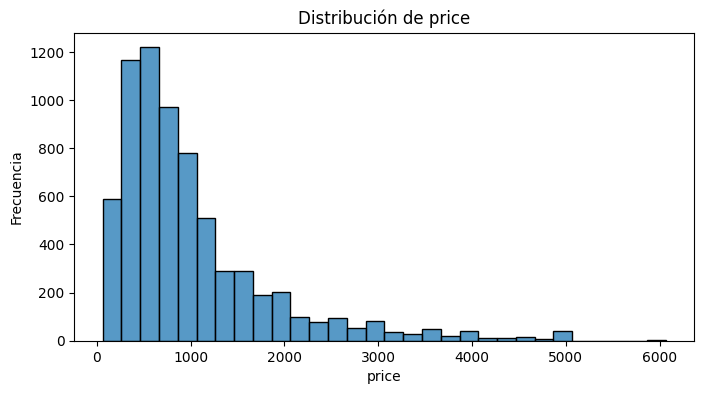

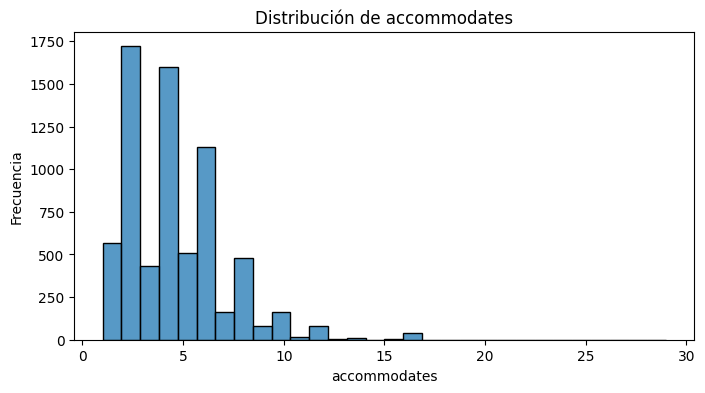

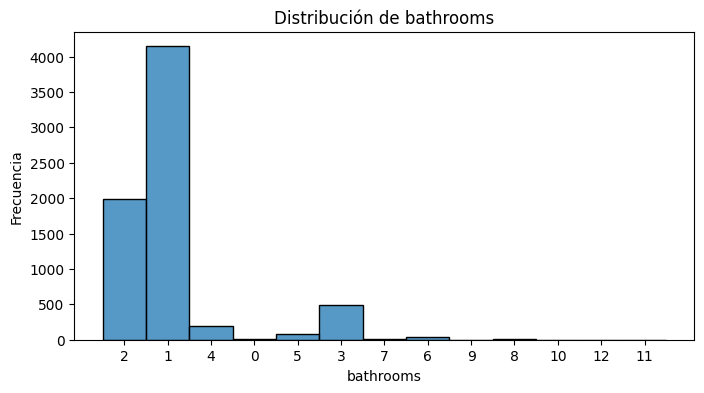

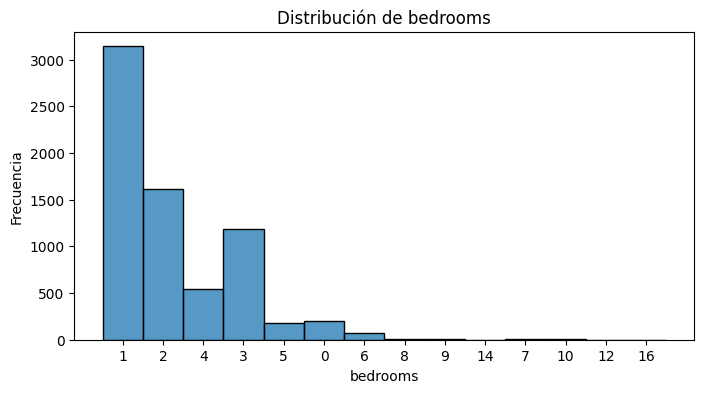

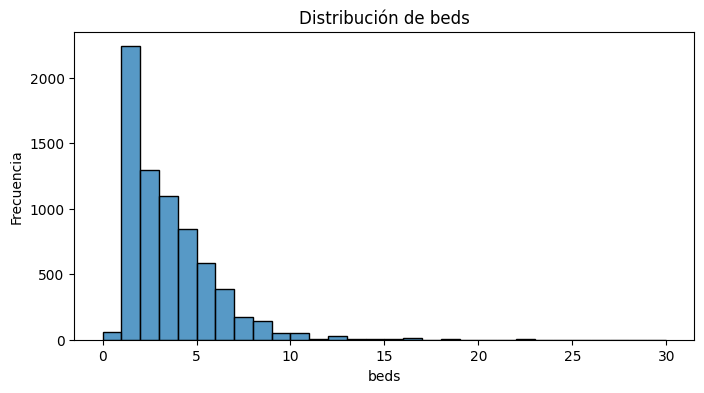

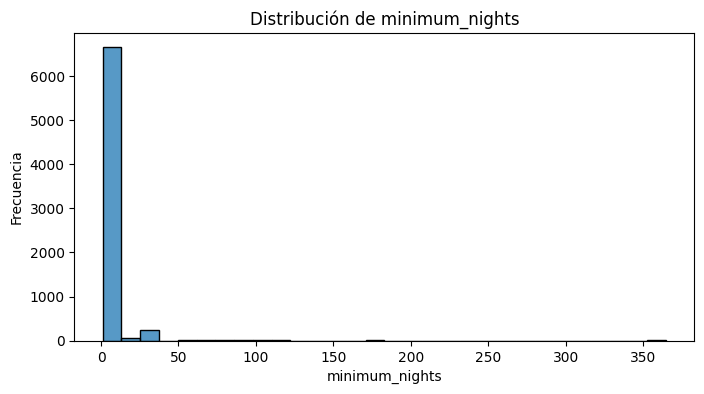

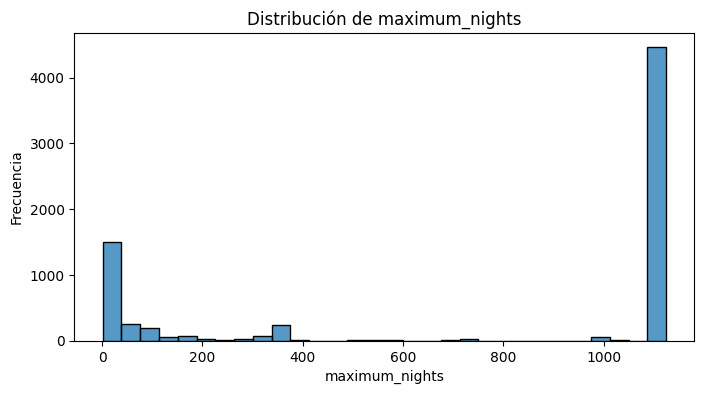

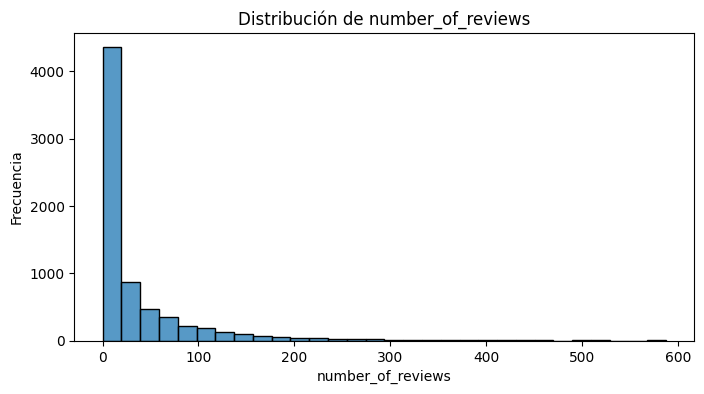

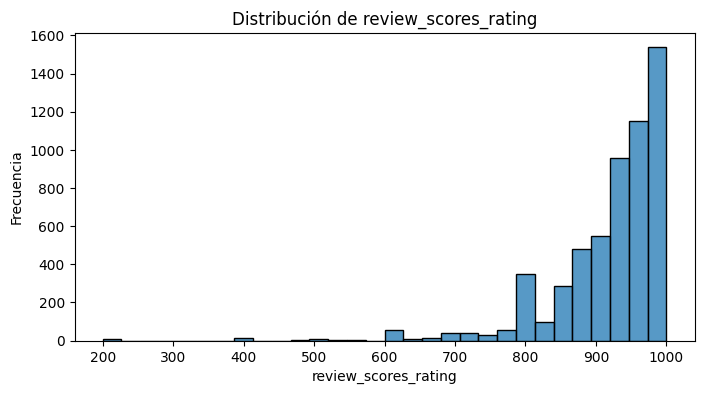

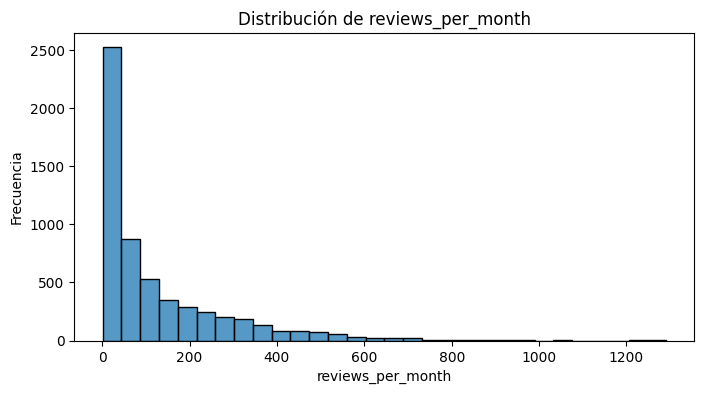

In [62]:
# 1. HISTOGRAMAS

for col in numericas:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], bins=30)

    plt.title(f"Distribución de {col}")

    plt.xlabel(col)

    plt.ylabel("Frecuencia")

    plt.show()

# Histogramas #

price: La mayoria de los alojamientos tienen precios inferiores a 1500€, hay un numero de alojamientos con precios muy elevados

Accommodates: la mayor parte de los alojamientos tienen capacidad entre 2 y 6 personas. Hay pocos con capacidad de mas de 10 habitaciones

bathrooms: La mayoria de los alojamientos disponen de entre 1 y 2 baños. Hay algunos alojamientos con bastantes baños. (Recomiendo revisar los registros que tienen muchos baños para confirmar que no sean errores)

bedrooms: La mayoria de alojamientos tienen entre 1 y 3 habitaciones. Hay otros que tienen muchas las habitaciones. (se podria comprobar, aunque pueden ser hoteles, hostales o villas)

beds: La mayoría de alojamientos cuentan con entre 1 y 4 camas. No hay muchos valores elevados. 

Minimum Nights: La mayoría de anuncios permiten reservas de corta duración. Existen algunos alojamientos que exigen estancias mínimas muy largas.
Maximum Nights: Hay muchos alojamientos con un maximo de estancia muy elevado, alrededor de 1125. 
Number of Reviews: La mayoría de alojamientos presentan un número reducido de reseñas, unos pocos concentran una gran cantidad.
Review Scores Rating: La mayoría de alojamientos tienen puntuaciones muy altas, concentrándose entre 900 y 1000. (Vigilar que los valores no son de 1 a 10)


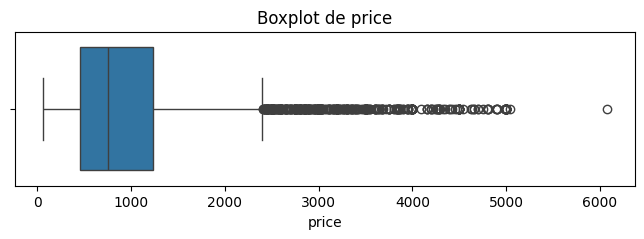

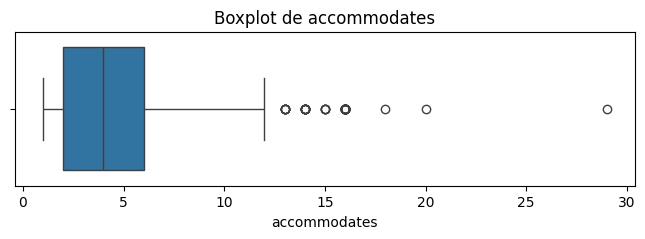

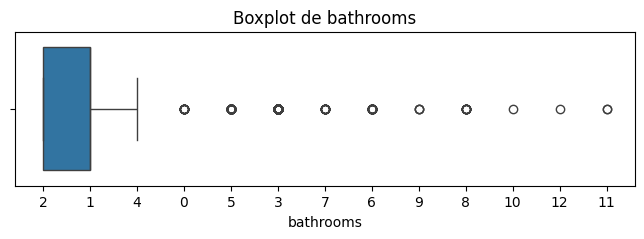

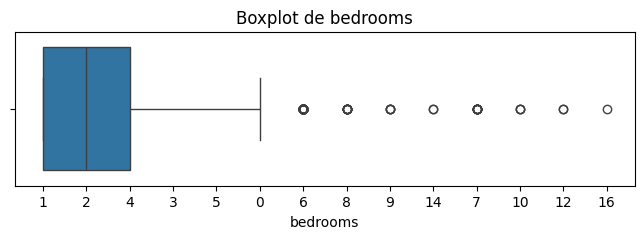

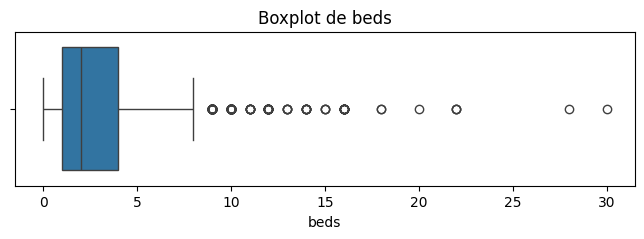

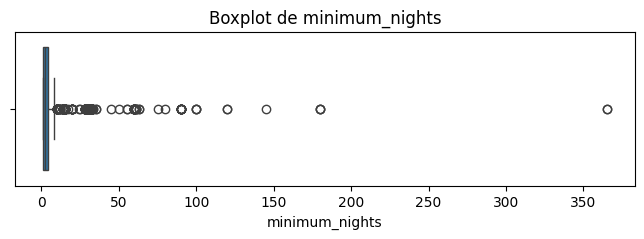

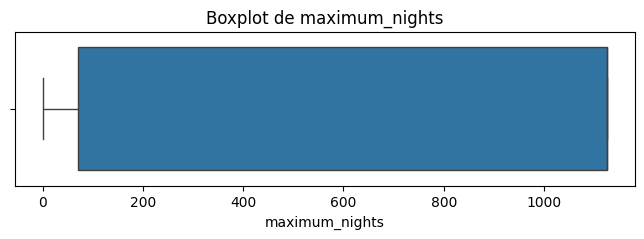

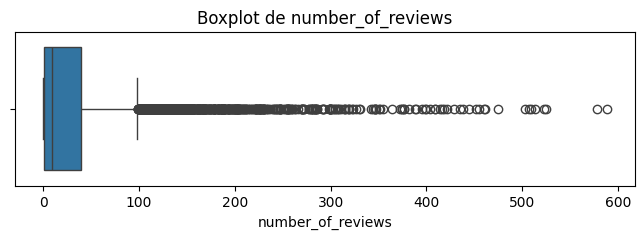

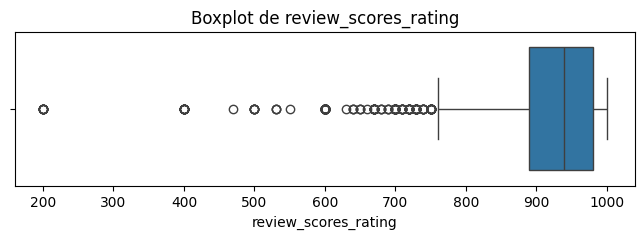

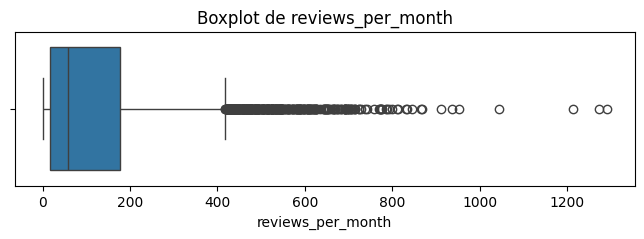

In [49]:
# BOXPLOTS (OUTLIERS)

for col in numericas:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot de {col}")

    plt.show()

Los Boxplots muestran que la mayoría de las variables numéricas presentan valores atípicos (outliers), especialmente en price, accommodates, bathrooms, bedrooms, beds, minimum_nights, number_of_reviews y reviews_per_month. En la mayoría de los casos los valores extremos corresponden a alojamientos con características poco frecuentes, como viviendas de gran capacidad, precios elevados o un elevado número de reseñas, por lo que no los consideraria como errores de registro. Se deberia tambien revisar algunos casos durante la fase de limpieza de datos para verificar su coherencia y determinar si deben mantenerse, transformarse o eliminarse.

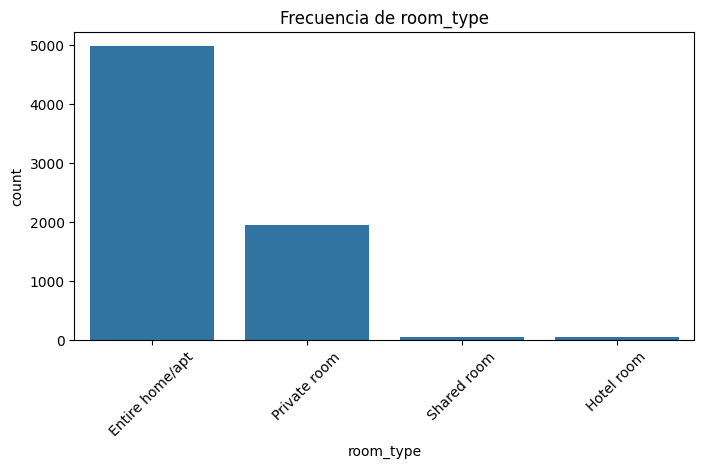

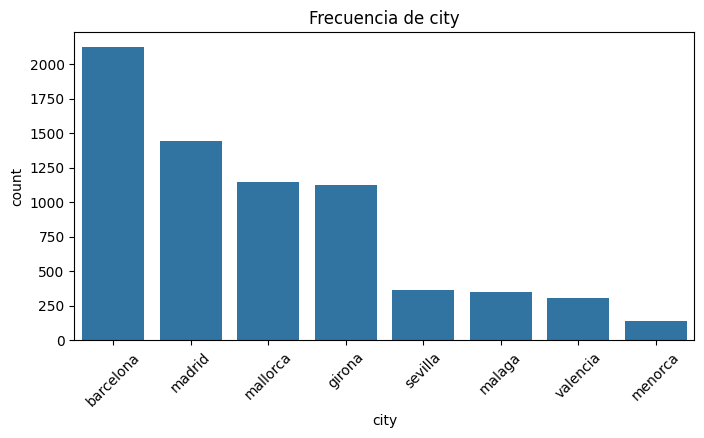

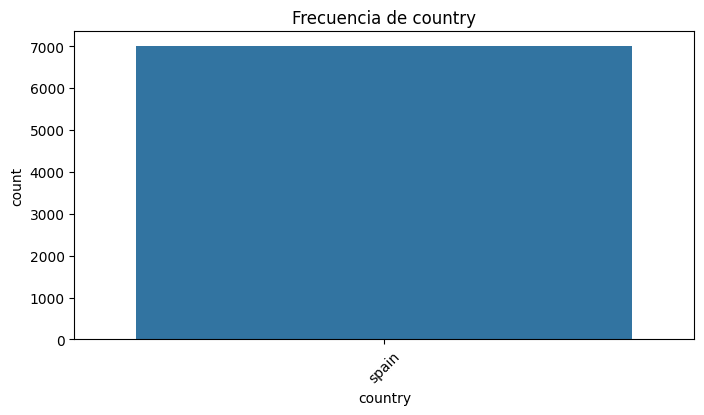

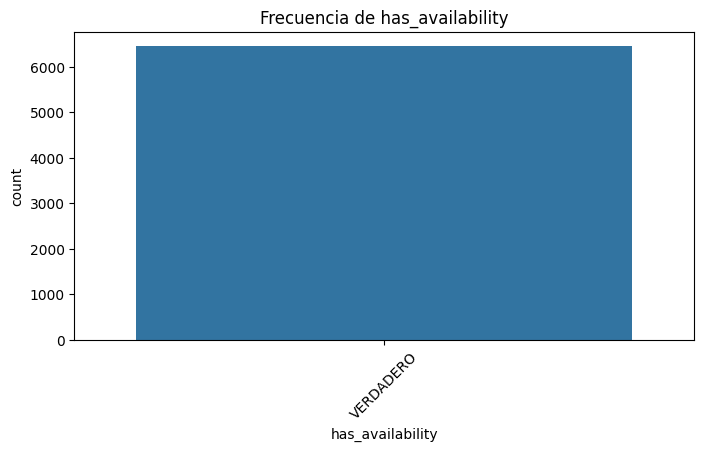

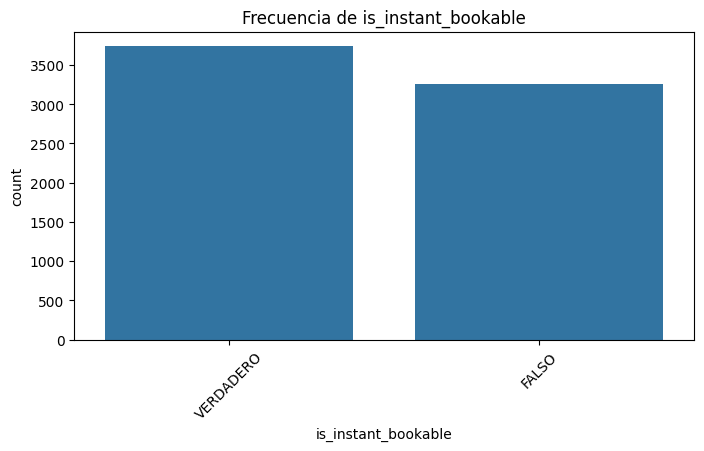

In [63]:
# COUNTPLOTS (CATEGÓRICAS)

for col in categoricas:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index)

    plt.title(f"Frecuencia de {col}")

    plt.xticks(rotation=45)

    plt.show()


En cuanto a las variables categoricas se observa que la mayoría de los alojamientos son de tipo "Entire home/apt", seguidos por "Private room", mientras que el resto tienen una presencia muy baja.

Barcelona es la ciudad con más alojamientos del dataset, seguida por Madrid, Mallorca y Girona. También se ve que las variables country y has_availability solo tienen un único valor en todos los registros, por lo que no aportan información relevante y (se podrian eliminar) durante la fase de limpieza de datos.

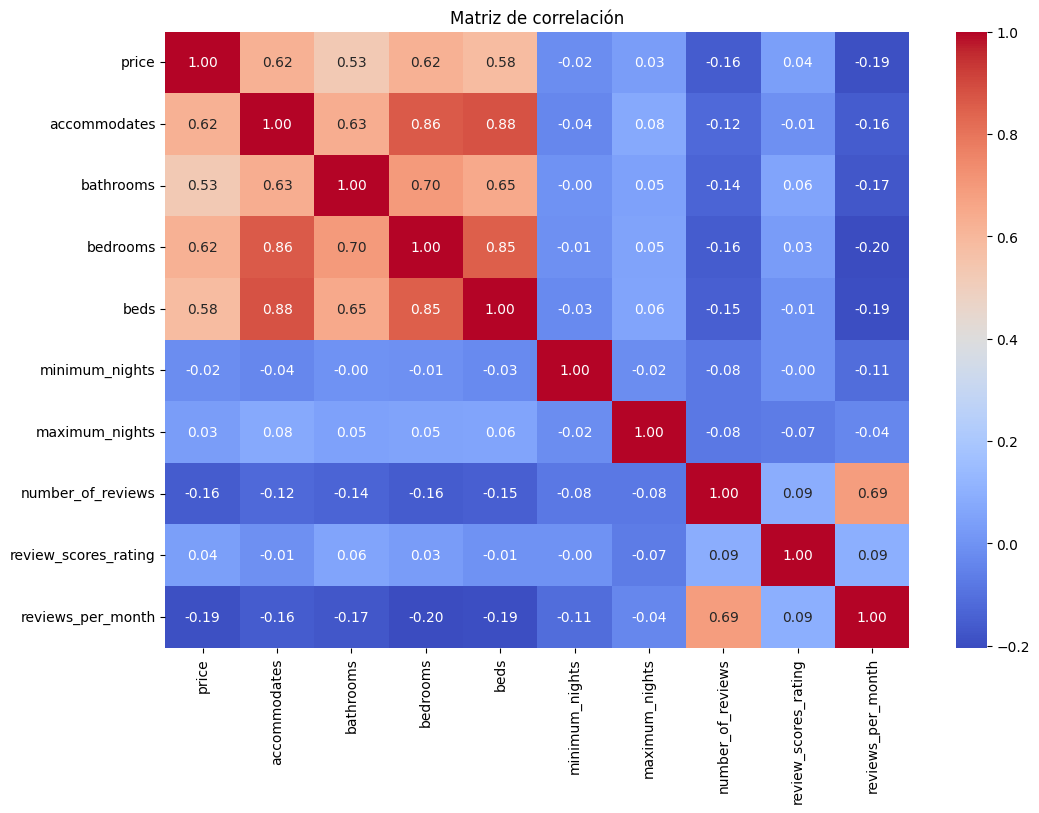

In [53]:
# 4. HEATMAP DE CORRELACIONES


plt.figure(figsize=(12,8))

sns.heatmap(
    df[numericas].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

Se observan correlaciones positivas entre el precio y variables relacionadas con el tamaño del alojamiento, como el número de habitaciones, camas, baños y capacidad.  Destaca la alta correlación entre el número de reseñas y las reseñas mensuales.

# Conclusiones generales del EDA

Se pueden extraer las siguientes conclusiones:

- El dataset contiene 7001 registros y 35 variables.
- Existen valores nulos principalmente en neighbourhood_district y en variables relacionadas con las valoraciones.
- No hay registros duplicados.
- Algunas variables como country y has_availability no aportan información relevante al tener un único valor.
- Hay valores atípicos en varias variables numéricas, aunque la mayoría parecen corresponder a alojamientos reales y no necesariamente a errores.
- Las variables relacionadas con el tamaño del alojamiento muestran las correlaciones más elevadas y muestran una relación moderada con el precio.

- Variables sin variabilidad: country y has_availability únicamente tienen un valor para todos los registros, por lo que comprobaría si tiene sentido mantenerlas en el dataset, ya que no aportan información para el análisis.

- Variables de alta cardinalidad: name y description contienen miles de valores únicos. Revisaría únicamente la existencia de valores nulos o posibles registros duplicados, ya que no tiene sentido unificar categorías en estas variables.

- Tipos de datos: combrobaria si variables como bathrooms, bedrooms y las fechas (first_review_date y last_review_date) tienen el tipo de dato más adecuado para el análisis y las convertiría si fuera necesario.

- Hay valores atípicos en las variables price, bathrooms, bedrooms, beds, minimum_nights, maximum_nights, number_of_reviews y reviews_per_month, por lo que he visto algunas valores atipicos son comprensibles como el maximo de noches o minimos, en cuanto a price creo necesario eliminar los registros en que salgan que hay 0 baños 

- bathrooms y	bedrooms pasarlos a numericos
- amenities_list considerar dividir toda la informacion si es necesario